In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from collections import defaultdict

In [36]:
# Define dataset paths
train_path = 'Training/'
test_path = 'Testing/'

# Define classes
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Classes:", classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Training set counts:
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing set counts:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


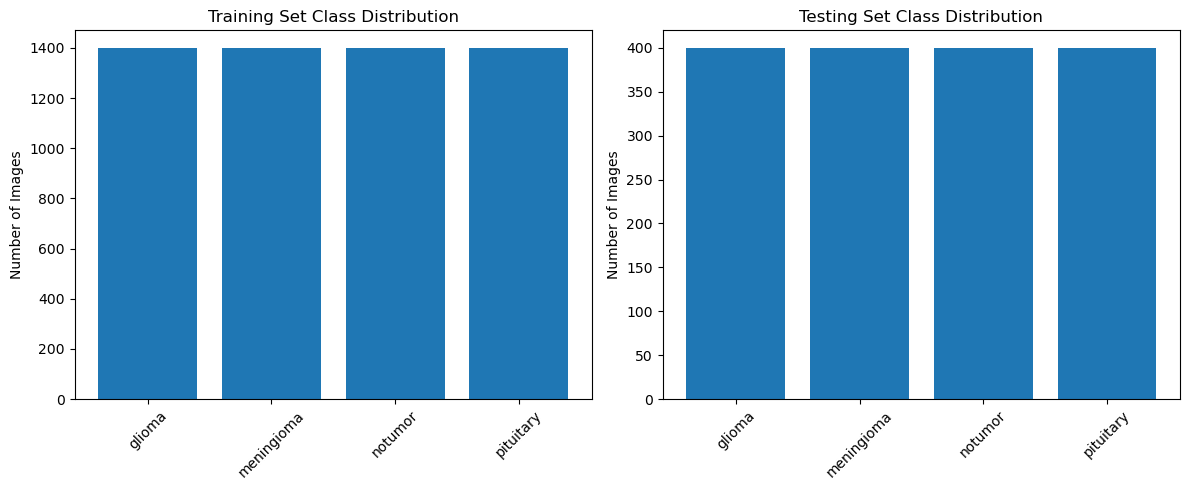

In [37]:
# Count images per class in Training set
train_counts = {}
for cls in classes:
    path = os.path.join(train_path, cls)
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        train_counts[cls] = count
    else:
        train_counts[cls] = 0

print("Training set counts:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

# Count images per class in Testing set
test_counts = {}
for cls in classes:
    path = os.path.join(test_path, cls)
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        test_counts[cls] = count
    else:
        test_counts[cls] = 0

print("\nTesting set counts:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(train_counts.keys(), train_counts.values())
ax1.set_title('Training Set Class Distribution')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(test_counts.keys(), test_counts.values())
ax2.set_title('Testing Set Class Distribution')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

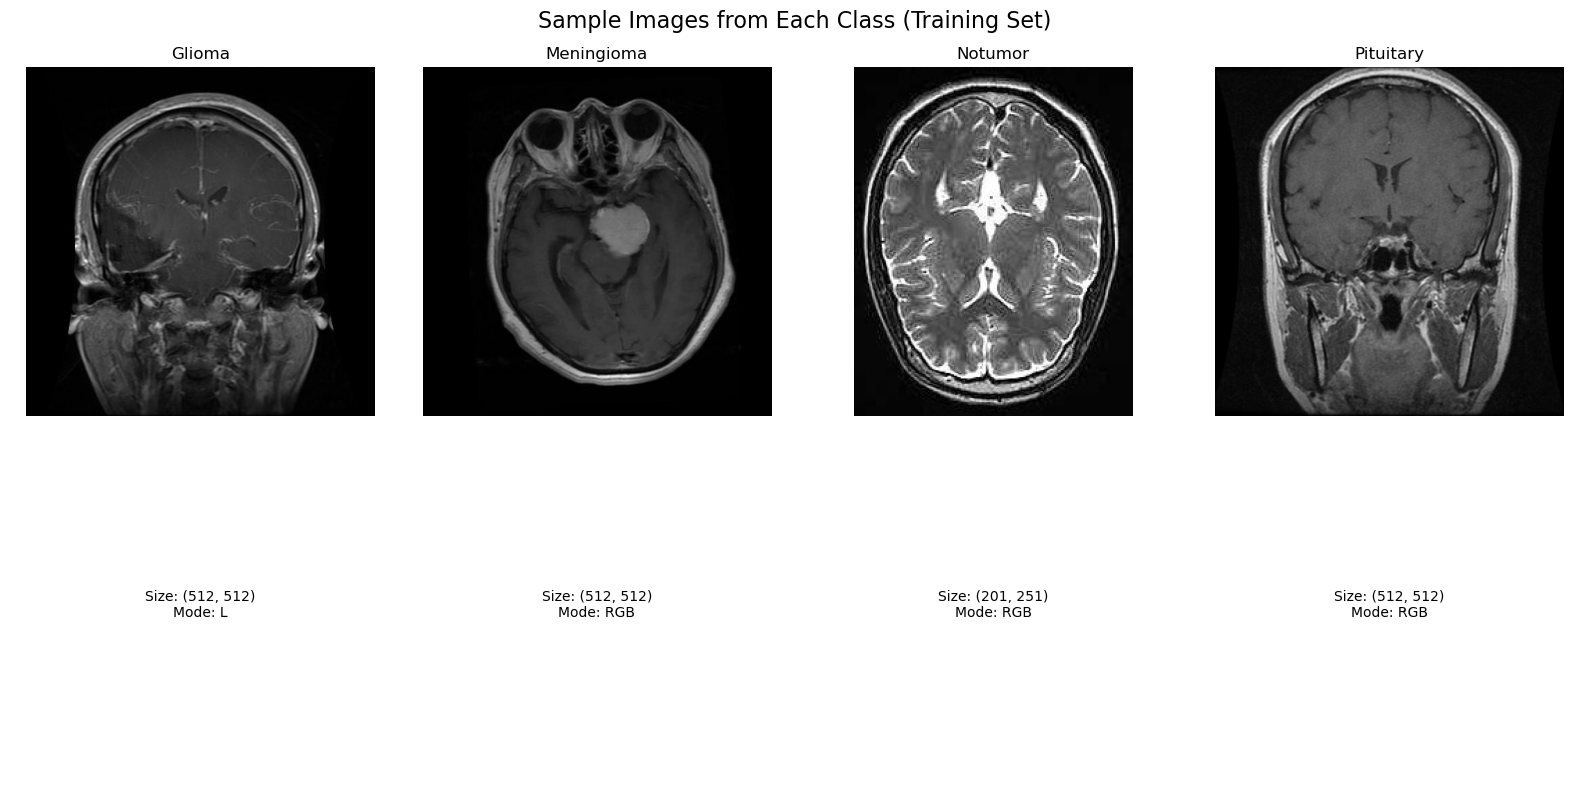

In [38]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images from Each Class (Training Set)', fontsize=16)

for i, cls in enumerate(classes):
    path = os.path.join(train_path, cls)
    if os.path.exists(path):
        images = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            # Take first image as sample
            img_path = os.path.join(path, images[0])
            img = Image.open(img_path)
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f'{cls.capitalize()}')
            axes[0, i].axis('off')
            
            # Show image info
            axes[1, i].text(0.5, 0.5, f'Size: {img.size}\nMode: {img.mode}', 
                           ha='center', va='center', transform=axes[1, i].transAxes)
            axes[1, i].axis('off')

plt.tight_layout()
plt.show()

C:\Users\2beto\AppData\Local\Temp\ipykernel_41072\2126574919.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([heights[cls] for cls in classes], labels=classes)
C:\Users\2beto\AppData\Local\Temp\ipykernel_41072\2126574919.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([widths[cls] for cls in classes], labels=classes)
C:\Users\2beto\AppData\Local\Temp\ipykernel_41072\2126574919.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([means[cls] for cls in classes], labels=classes)
C:\Users\2beto\AppData\Local\Temp\ipykernel_41072\2126574919.py:51: Matplotl

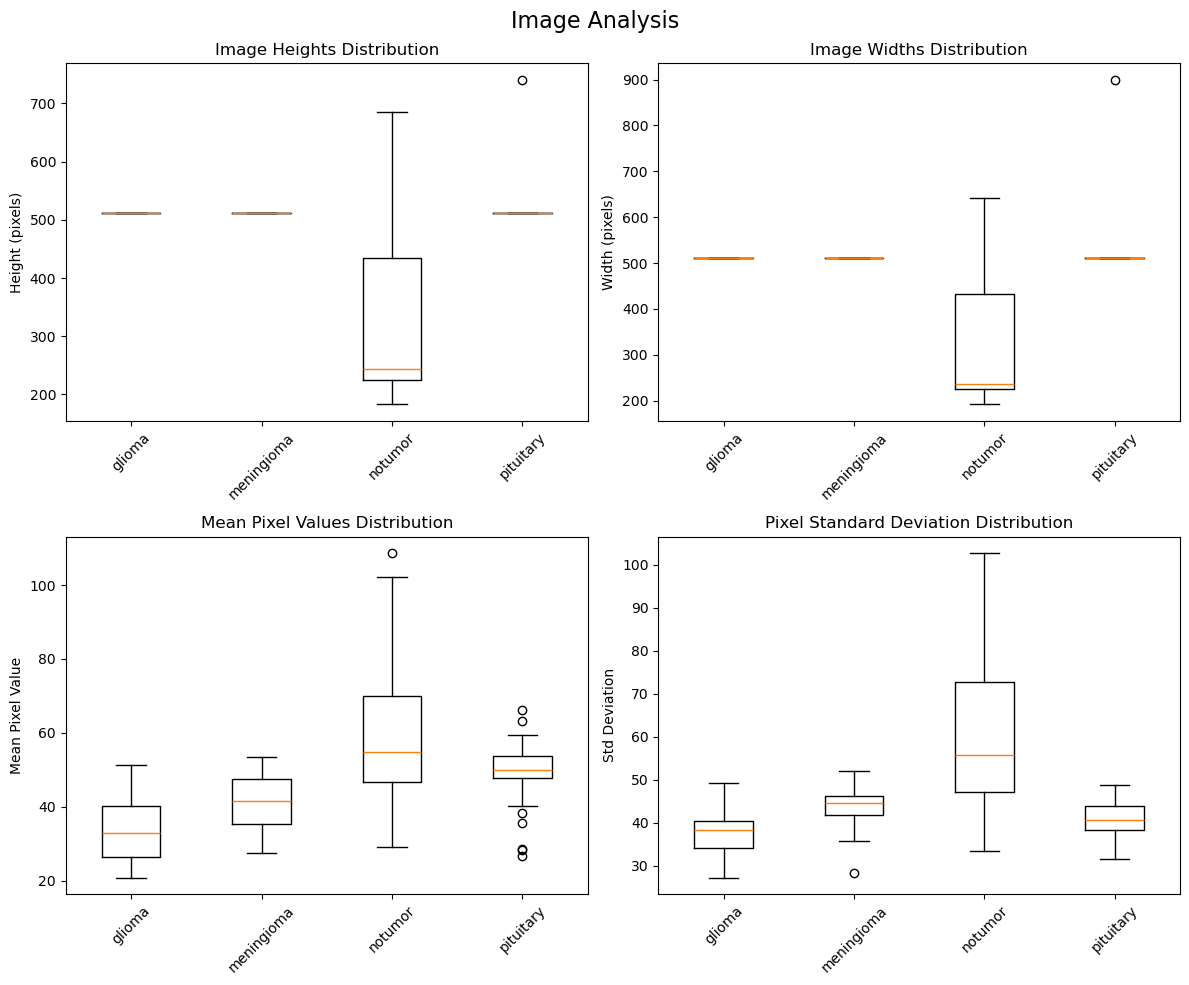

Summary Statistics:

Glioma:
  Images analyzed: 50
  Height - Mean: 512.0, Std: 0.0
  Width - Mean: 512.0, Std: 0.0
  Pixel Mean - Mean: 33.4, Std: 7.8

Meningioma:
  Images analyzed: 50
  Height - Mean: 512.0, Std: 0.0
  Width - Mean: 512.0, Std: 0.0
  Pixel Mean - Mean: 41.4, Std: 7.1

Notumor:
  Images analyzed: 50
  Height - Mean: 324.0, Std: 142.5
  Width - Mean: 319.9, Std: 146.5
  Pixel Mean - Mean: 58.9, Std: 19.3

Pituitary:
  Images analyzed: 50
  Height - Mean: 516.6, Std: 32.1
  Width - Mean: 519.8, Std: 54.3
  Pixel Mean - Mean: 49.5, Std: 7.8


In [39]:
# Analyze image dimensions and statistics 
dimensions = defaultdict(list)
pixel_stats = defaultdict(list)

for cls in classes:
    path = os.path.join(train_path, cls)
    if os.path.exists(path):
        images = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:50]  # Sample 50 images per class
        for img_file in images:
            img_path = os.path.join(path, img_file)
            try:
                img = Image.open(img_path)
                img_array = np.array(img)
                dimensions[cls].append(img_array.shape)
                pixel_stats[cls].append({
                    'mean': np.mean(img_array),
                    'std': np.std(img_array),
                    'min': np.min(img_array),
                    'max': np.max(img_array)
                })
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

# Plot dimension distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Image Analysis', fontsize=16)

# Heights
heights = {cls: [dim[0] for dim in dimensions[cls]] for cls in classes}
axes[0, 0].boxplot([heights[cls] for cls in classes], labels=classes)
axes[0, 0].set_title('Image Heights Distribution')
axes[0, 0].set_ylabel('Height (pixels)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Widths
widths = {cls: [dim[1] for dim in dimensions[cls]] for cls in classes}
axes[0, 1].boxplot([widths[cls] for cls in classes], labels=classes)
axes[0, 1].set_title('Image Widths Distribution')
axes[0, 1].set_ylabel('Width (pixels)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Mean pixel values
means = {cls: [stat['mean'] for stat in pixel_stats[cls]] for cls in classes}
axes[1, 0].boxplot([means[cls] for cls in classes], labels=classes)
axes[1, 0].set_title('Mean Pixel Values Distribution')
axes[1, 0].set_ylabel('Mean Pixel Value')
axes[1, 0].tick_params(axis='x', rotation=45)

# Standard deviation of pixel values
stds = {cls: [stat['std'] for stat in pixel_stats[cls]] for cls in classes}
axes[1, 1].boxplot([stds[cls] for cls in classes], labels=classes)
axes[1, 1].set_title('Pixel Standard Deviation Distribution')
axes[1, 1].set_ylabel('Std Deviation')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
for cls in classes:
    if dimensions[cls]:
        heights_cls = [dim[0] for dim in dimensions[cls]]
        widths_cls = [dim[1] for dim in dimensions[cls]]
        print(f"\n{cls.capitalize()}:")
        print(f"  Images analyzed: {len(dimensions[cls])}")
        print(f"  Height - Mean: {np.mean(heights_cls):.1f}, Std: {np.std(heights_cls):.1f}")
        print(f"  Width - Mean: {np.mean(widths_cls):.1f}, Std: {np.std(widths_cls):.1f}")
        if pixel_stats[cls]:
            means_cls = [stat['mean'] for stat in pixel_stats[cls]]
            print(f"  Pixel Mean - Mean: {np.mean(means_cls):.1f}, Std: {np.std(means_cls):.1f}")
